In [1]:
from scipy.io import loadmat
import torch
import numpy as np

In [2]:
data = loadmat("Data/MAT/01D100066_timit_hear_only_19082018_1232_20180819_123258_band_8_13_notch50_fil (1).mat")
eeg_Data = data['a01D100066_timit_hear_only_19082018_1232_20180819_123258_band_8_13_notch50_filmff']
eeg_Data.shape

(129, 83934)

In [4]:
x_tensor.shape, y_raw_tensor.shape, input_chans.shape, input_time.shape, input_mask.shape, y_freq.shape

(torch.Size([1, 1000, 200]),
 torch.Size([1, 1000, 200]),
 torch.Size([1, 1000]),
 torch.Size([1, 1000]),
 torch.Size([1, 1000]),
 torch.Size([1]))

In [5]:
import sys
sys.path.insert(0, "./NeuroLM")

from model.model_vq import VQ
from model.model_neural_transformer import NTConfig

import torch

/home/taneti-sanjay/Projects/Research/EEGSSL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
vq_path = ".weights/NeuroLm/checkpoints/VQ.pt"
vq = torch.load(vq_path, map_location="cpu", weights_only=False)

In [7]:
encoder_config = NTConfig(**vq["encoder_args"])
decoder_config = NTConfig(**vq["decoder_args"])

model = VQ(
    encoder_config=encoder_config,
    decoder_config=decoder_config
)

{}
Final encoder config NTConfig(block_size=1024, patch_size=200, num_classes=0, in_chans=1, out_chans=16, use_mean_pooling=True, init_scale=0.001, n_layer=12, n_head=12, n_embd=768, dropout=0.0, bias=False)
Final decoder config NTConfig(block_size=1024, patch_size=200, num_classes=0, in_chans=128, out_chans=16, use_mean_pooling=True, init_scale=0.001, n_layer=4, n_head=12, n_embd=768, dropout=0.0, bias=False)


In [8]:
state_dict = vq["model"]

clean_state_dict = {}

for k, v in state_dict.items():
    if k.startswith("_orig_mod.VQ."):
        new_k = k[len("_orig_mod.VQ."):]
        clean_state_dict[new_k] = v
        
model.load_state_dict(clean_state_dict)

<All keys matched successfully>

In [11]:
NUM_CHANNELS = 128  # Passing all 128 EEG channels!
TIME_STEPS = 6      # 6 time steps per channel (6 * 200 = 1200 raw samples = 4.8s at 250Hz)
PATCH_SIZE = 200

# 1. Crop raw data to fit this window (128 channels, 1200 samples)
total_samples_needed = TIME_STEPS * PATCH_SIZE
eeg_segment = eeg_Data[:NUM_CHANNELS, :total_samples_needed] # Shape: (128, 1200)

# 2. Reshape into patches: (128, 6, 200)
eeg_patched = eeg_segment.reshape(NUM_CHANNELS, TIME_STEPS, PATCH_SIZE)

# 3. Positional indices across all 128 channels
# Channel IDs: [0..127] each repeated 6 times -> [0,0,0,0,0,0, 1,1,1,1,1,1, ..., 127,127,127,127,127,127]
chan_ids = np.repeat(np.arange(NUM_CHANNELS), TIME_STEPS)

# Time IDs: [0..5] repeated for each of the 128 channels -> [0,1,2,3,4,5, 0,1,2,3,4,5, ...]
time_ids = np.tile(np.arange(TIME_STEPS), NUM_CHANNELS)

# 4. Flatten spatial and temporal dimensions into sequence length N = 768
N = NUM_CHANNELS * TIME_STEPS  # 768 patches
eeg_flat = eeg_patched.reshape(N, PATCH_SIZE)

# 5. Format PyTorch Tensors
x_tensor = torch.tensor(eeg_flat, dtype=torch.float32).unsqueeze(0)       # (1, 768, 200)
y_raw_tensor = torch.tensor(eeg_flat, dtype=torch.float32).unsqueeze(0)   # (1, 768, 200)
input_chans = torch.tensor(chan_ids, dtype=torch.long).unsqueeze(0)       # (1, 768)
input_time = torch.tensor(time_ids, dtype=torch.long).unsqueeze(0)       # (1, 768)

input_mask = torch.zeros((1, N), dtype=torch.float32)
y_freq = torch.tensor([250.0], dtype=torch.float32)

# 6. Forward pass with all 128 channels
with torch.no_grad():
    comp = model(
        y_raw=y_raw_tensor,
        y_freq=y_freq,
        x=x_tensor,
        input_mask=input_mask,
        input_chans=input_chans,
        input_time=input_time
    )

/home/taneti-sanjay/Projects/Research/EEGSSL/NeuroLM/model/model_vq.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/taneti-sanjay/Projects/Research/EEGSSL/NeuroLM/model/model_vq.py:139: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 768, 100])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  rec_loss = self.loss_fn(rec, target)


In [ ]:
with torch.no_grad():
    # Step 1: Encode input into quantized latents
    quantize, embed_ind, emb_loss,   = model.encode(
        x=x_tensor, 
        input_chans=input_chans, 
        input_time=input_time, 
        mask=input_mask
    )
    
    # Step 2: Decode quantized latents back into raw & frequency domain signals
    xrec_freq, xrec_raw = model.decode(
        quantize=quantize, 
        input_chans=input_chans, 
        input_time=input_time, 
        mask=input_mask
    )

print("Frequency Reconstruction Shape:", xrec_freq.shape) # (1, 768, 768)
print("Raw Time-Domain Signal Shape:",  xrec_raw.shape)  # (1, 768, 200) -> Exact match to x_tensor!

/home/taneti-sanjay/Projects/Research/EEGSSL/NeuroLM/model/model_vq.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Frequency Reconstruction Shape: torch.Size([1, 768, 100])
Raw Time-Domain Signal Shape: torch.Size([1, 768, 200])


In [21]:
comp[1].shape, x_tensor.shape

(torch.Size([1, 768, 768]), torch.Size([1, 768, 200]))

In [22]:
comp

(tensor(337728.3438),
 tensor([[[ 0.3923,  0.9952, -1.2214,  ..., -0.5626,  0.0812,  0.7953],
          [ 0.4106,  1.8663, -0.2592,  ..., -1.8036, -0.2146,  0.9811],
          [ 0.8313,  1.1912, -0.2507,  ..., -1.5157, -0.4329,  0.4443],
          ...,
          [ 0.4250,  1.1443, -0.1893,  ..., -1.8346, -0.7530,  0.4660],
          [ 0.4165,  1.1871, -0.1882,  ..., -1.7869, -0.7767,  0.4740],
          [ 0.3382,  1.3038, -0.2360,  ..., -1.8813, -0.7319,  0.4607]]]),
 {'train/quant_loss': tensor(0.0029),
  'train/rec_freq_loss': tensor(62500.),
  'train/rec_raw_loss': tensor(275228.3438),
  'train/total_loss': tensor(337728.3438)})

In [10]:
max_time_steps = model.encoder.time_embed.weight.shape[0]
print(f"Max supported time index: {max_time_steps - 1}")

# Check max allowed channels
max_channels = model.encoder.pos_embed.weight.shape[0]
print(f"Max supported channel index: {max_channels - 1}")

Max supported time index: 63
Max supported channel index: 255


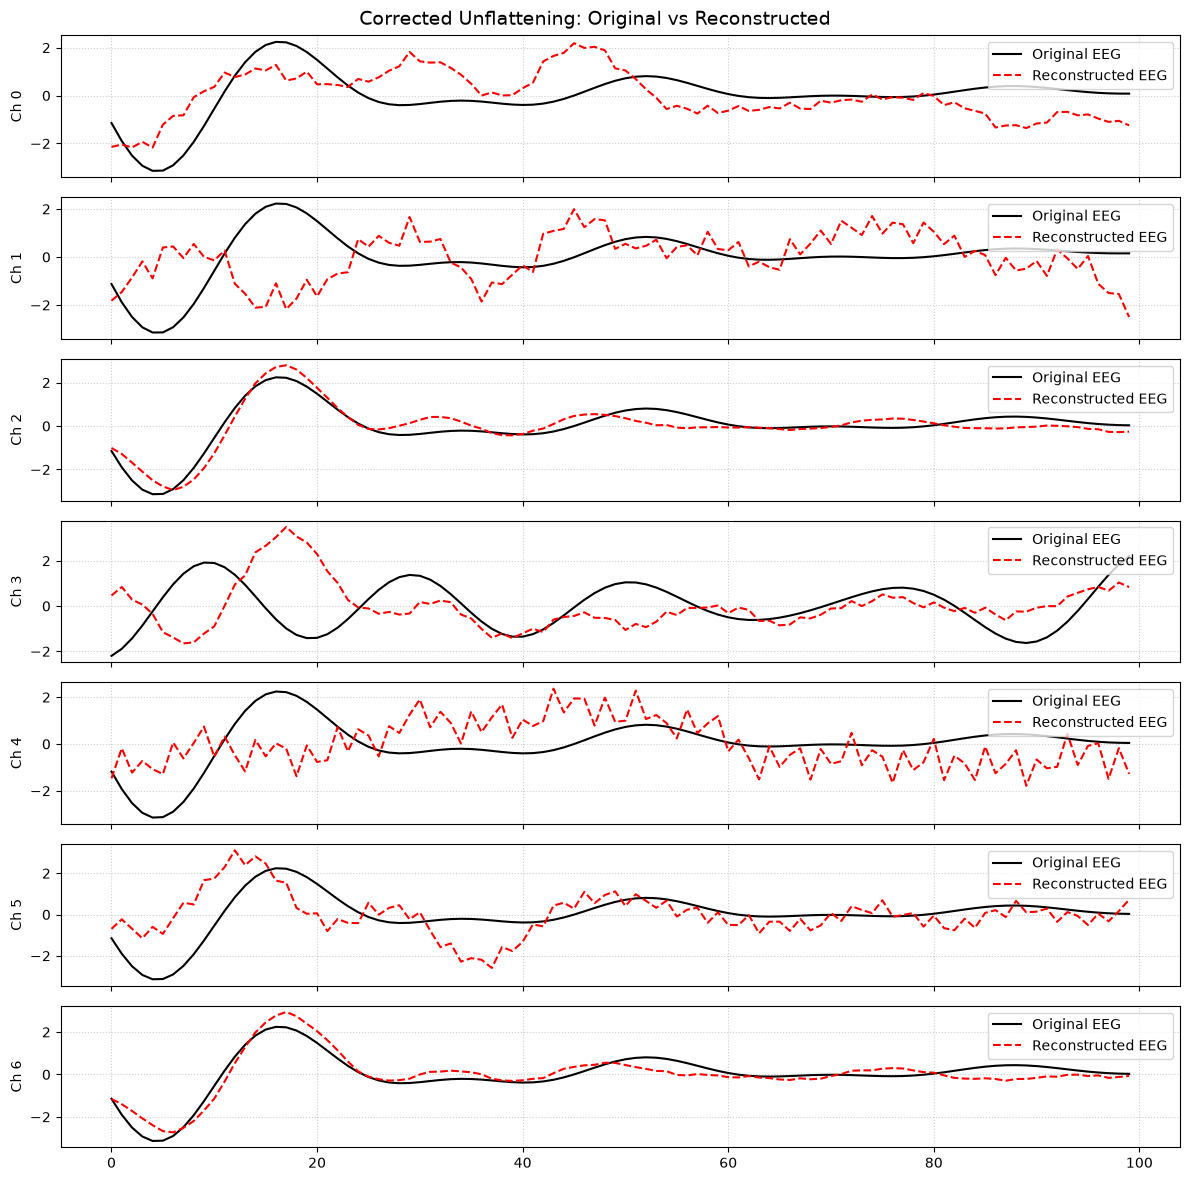

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Unflatten correctly based on C-contiguous memory layout
# x_tensor and xrec_raw have shape (1, 768, 200)
x_orig_correct = x_tensor.squeeze(0).reshape(128, 6 * 200).cpu().numpy()
x_recon_correct = xrec_raw.squeeze(0).reshape(128, 6 * 200).cpu().numpy()

orig_100 = x_orig_correct[:, :100]
recon_100 = x_recon_correct[:, :100]

# 3. Z-score normalize per channel for fair comparison
eps = 1e-8
orig_norm  = (orig_100 - orig_100.mean(axis=1, keepdims=True)) / (orig_100.std(axis=1, keepdims=True) + eps)
recon_norm = (recon_100 - recon_100.mean(axis=1, keepdims=True)) / (recon_100.std(axis=1, keepdims=True) + eps)

# Plot Ch 0, Ch 1, Ch 2
fig, axes = plt.subplots(7, 1, figsize=(12, 12), sharex=True)
for ch in range(7):
    axes[ch].plot(orig_norm[ch], label="Original EEG", color="black")
    axes[ch].plot(recon_norm[ch], label="Reconstructed EEG", color="red", linestyle="--")
    axes[ch].set_ylabel(f"Ch {ch}")
    axes[ch].legend(loc="upper right")
    axes[ch].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Corrected Unflattening: Original vs Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()